# 02_regression.ipynb

## End-to-End Machine Learning Regression Pipeline for Song Release Year Prediction

This notebook implements a complete end-to-end **Machine Learning regression pipeline** using `midterm-regresi-dataset.csv`.

**Objective:** predict a continuous target value, specifically the song release year, using numerical audio features.

According to the dataset description, the first value in each row represents the target label, while all remaining values are numerical audio features. Since the feature names are not human-readable, this notebook assigns systematic names such as `feature_1`, `feature_2`, and so on.

**Main workflow:**
1. Environment setup and library import
2. Dataset loading from Google Drive
3. Dataset structure validation
4. Exploratory Data Analysis (EDA)
5. Missing value handling
6. Outlier handling
7. Feature preparation
8. Train-test split
9. Baseline model training
10. Hyperparameter tuning using Optuna
11. Experiment tracking using MLflow
12. Model evaluation using regression metrics
13. Result interpretation using LIME
14. Final conclusion

> This notebook is intentionally written with detailed markdown explanations and code comments for every major step, so the workflow is clear and academically aligned with the UTS requirements.

In [1]:
# ============================================================
# 1. Install required dependencies if missing
# ============================================================
# Optuna is used for hyperparameter tuning.
# MLflow is used for experiment tracking.
# LIME is used for local model interpretation.

import sys
import subprocess
import importlib.util


def install_if_missing(package_name, import_name=None):
    """Install a package only when it is not already available."""
    if import_name is None:
        import_name = package_name
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package_name])
    else:
        print(f"{package_name} is already installed.")

install_if_missing("optuna")
install_if_missing("mlflow")
install_if_missing("lime")

Installing optuna ...
Installing mlflow ...
Installing lime ...


In [2]:
# ============================================================
# 2. Import libraries
# ============================================================
# The libraries below cover data manipulation, visualization,
# preprocessing, modeling, evaluation, tuning, tracking, and interpretation.

import os
import gc
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
import mlflow
import mlflow.sklearn

from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The dataset is loaded from Google Drive using the following path:

```python
/content/drive/MyDrive/midterm-regresi-dataset.csv
```

This notebook reads the dataset without assuming that the CSV file has a header. This is important because the dataset description states that the first value in each row is the target label, not a column name.

A full dataset read is attempted by default. If the runtime environment is limited, the optional `USE_SAMPLE` variable can be changed to `True`, but the default configuration below uses the available dataset file directly.

In [3]:
# ============================================================
# 3. Mount Google Drive and load the regression dataset
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive mounted successfully.")
except Exception:
    print("Google Drive is already mounted or this is not a Colab environment.")

DATA_PATH = "/content/drive/MyDrive/midterm-regresi-dataset.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH}. Please make sure midterm-regresi-dataset.csv is located in MyDrive."
    )

# Full read by default. Set USE_SAMPLE=True only if the runtime is too limited.
USE_SAMPLE = False
NROWS = 120_000

if USE_SAMPLE:
    raw_df = pd.read_csv(DATA_PATH, header=None, nrows=NROWS)
else:
    raw_df = pd.read_csv(DATA_PATH, header=None)

print("Dataset loaded successfully.")
print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())

Mounted at /content/drive
Google Drive mounted successfully.
Dataset loaded successfully.
Raw dataset shape: (515345, 91)


,0,1,2,3,4,5,6,7,8,9,...,81,82,83,84,85,86,87,88,89,90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 4. Dataset Structure Validation and Column Naming

The dataset is expected to have:

- Column 0 as the target variable (`target_year`)
- All remaining columns as numerical audio features

This section converts all values to numeric format. If a non-numeric header row accidentally exists in the file, it will be converted to missing values and removed safely.

In [4]:
# ============================================================
# 4. Validate structure and assign clear column names
# ============================================================

# Convert all columns to numeric. Invalid values become NaN and will be handled safely.
raw_df = raw_df.apply(pd.to_numeric, errors="coerce")

# Remove rows where the target is missing.
raw_df = raw_df.dropna(subset=[0]).reset_index(drop=True)

if raw_df.shape[1] < 2:
    raise ValueError("The dataset must contain at least one target column and one feature column.")

feature_count = raw_df.shape[1] - 1
columns = ["target_year"] + [f"feature_{i}" for i in range(1, feature_count + 1)]
raw_df.columns = columns

# Downcast numeric values to reduce memory usage while keeping all rows.
for col in raw_df.columns:
    raw_df[col] = pd.to_numeric(raw_df[col], downcast="float")

print("Cleaned dataset shape:", raw_df.shape)
print("Number of features:", feature_count)
display(raw_df.head())

Cleaned dataset shape: (515345, 91)
Number of features: 90


,target_year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001.0,49.943569,21.47114,73.077499,8.74861,-17.406281,-13.099050,-25.01202,-12.23257,7.830890,...,13.016200,-54.405479,58.993671,15.373440,1.11144,-23.087931,68.407951,-1.82223,-27.463480,2.263270
1,2001.0,48.732151,18.42930,70.326790,12.94636,-10.324370,-24.837770,8.76630,-0.92019,18.765480,...,5.668120,-19.680731,33.049641,42.878361,-9.90378,-32.227879,70.493881,12.04941,58.434528,26.920610
2,2001.0,50.957142,31.85602,55.818508,13.41693,-6.578980,-18.549400,-3.27872,-2.35035,16.070169,...,3.038000,26.058661,-50.927792,10.937920,-0.07568,43.201302,-115.006981,-0.05859,39.670681,-0.663450
3,2001.0,48.247501,-1.89837,36.297722,2.58776,0.971700,-26.216829,5.05097,-10.34124,3.550050,...,34.573372,-171.707336,-16.967051,-46.676170,-12.51516,82.580612,-72.089928,9.90558,199.629715,18.853821
4,2001.0,50.970200,42.20998,67.099640,8.46791,-15.852790,-16.814091,-12.48207,-9.37636,12.636990,...,9.926610,-55.957241,64.927116,-17.725220,-1.49237,-7.500350,51.766312,7.88713,55.669258,28.749029


## 5. Exploratory Data Analysis

EDA helps understand the target distribution, feature scale, missing values, and possible data quality issues before modeling. Since this is a regression task, the target variable is continuous/numerical and will be evaluated using regression metrics such as MAE, RMSE, and R².

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   target_year  515345 non-null  float32
 1   feature_1    515345 non-null  float32
 2   feature_2    515345 non-null  float32
 3   feature_3    515345 non-null  float32
 4   feature_4    515345 non-null  float32
 5   feature_5    515345 non-null  float32
 6   feature_6    515345 non-null  float32
 7   feature_7    515345 non-null  float32
 8   feature_8    515345 non-null  float32
 9   feature_9    515345 non-null  float32
 10  feature_10   515345 non-null  float32
 11  feature_11   515345 non-null  float32
 12  feature_12   515345 non-null  float32
 13  feature_13   515345 non-null  float32
 14  feature_14   515345 non-null  float64
 15  feature_15   515345 non-null  float64
 16  feature_16   515345 non-null  float64
 17  feature_17   515345 non-null  float32
 18  fea

,target_year
count,515345.000000
mean,1998.396851
std,12.595524
min,1922.000000
25%,1994.000000
50%,2002.000000
75%,2006.000000
max,2011.000000


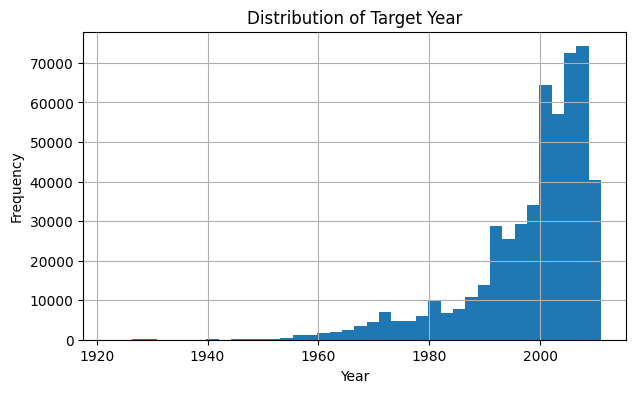

Feature summary sample:


,count,mean,std,min,25%,50%,75%,max
feature_1,515345.0,43.387135,6.066978,1.749000,39.954689,44.258499,47.833889,61.970139
feature_2,515345.0,1.289554,51.574780,-337.092499,-26.059521,8.417850,36.124008,384.065735
feature_3,515345.0,8.658348,35.264637,-301.005066,-11.462710,10.476320,29.764820,322.851440
feature_4,515345.0,1.164124,16.321194,-154.183578,-8.487500,-0.652840,8.787540,335.771820
feature_5,515345.0,-6.553600,22.858780,-181.953369,-20.666451,-6.007770,7.741870,262.068878
feature_6,515345.0,-9.521976,12.856465,-81.794289,-18.440990,-11.188390,-2.388960,166.236893
feature_7,515345.0,-2.391089,14.570294,-188.214005,-10.780600,-2.046670,6.508580,172.402679
feature_8,515345.0,-1.793235,7.963030,-72.503853,-6.468420,-1.736450,2.913450,126.741272
feature_9,515345.0,3.727875,10.581767,-126.479042,-2.293660,3.822310,9.961820,146.297943
feature_10,515345.0,1.882385,6.529541,-41.631660,-2.444850,1.783520,6.147220,60.345348


In [5]:
# ============================================================
# 5. Basic EDA
# ============================================================

print("Dataset information:")
print(raw_df.info())

print("Target statistics:")
display(raw_df["target_year"].describe().to_frame("target_year"))

plt.figure(figsize=(7, 4))
raw_df["target_year"].hist(bins=40)
plt.title("Distribution of Target Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

print("Feature summary sample:")
display(raw_df.drop(columns=["target_year"]).describe().T.head(10))

In [6]:
# ============================================================
# 6. Missing value analysis
# ============================================================

missing_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_ratio": raw_df.isna().mean()
}).sort_values("missing_ratio", ascending=False)

print("Top 15 columns with the highest missing value ratio:")
display(missing_summary.head(15))

Top 15 columns with the highest missing value ratio:


,missing_count,missing_ratio
target_year,0,0.0
feature_1,0,0.0
feature_2,0,0.0
feature_3,0,0.0
feature_4,0,0.0
feature_5,0,0.0
feature_6,0,0.0
feature_7,0,0.0
feature_8,0,0.0
feature_9,0,0.0


## 6. Feature and Target Preparation

The first column is used as the target variable. All other columns are used as input features.

Data cleaning decisions:
- Rows with missing target values are removed because a supervised regression model cannot learn without labels.
- Constant features are removed because they do not provide useful predictive information.
- Missing feature values are handled later inside the preprocessing pipeline using median imputation.

In [7]:
# ============================================================
# 7. Prepare features and target
# ============================================================

TARGET = "target_year"

X = raw_df.drop(columns=[TARGET]).copy()
y = raw_df[TARGET].astype(float).copy()

# Remove constant features because they do not help prediction.
constant_cols = [col for col in X.columns if X[col].nunique(dropna=True) <= 1]
if len(constant_cols) > 0:
    X = X.drop(columns=constant_cols)

feature_cols = X.columns.tolist()

print("Removed constant features:", len(constant_cols))
print("Final number of usable features:", len(feature_cols))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

gc.collect()

Removed constant features: 0
Final number of usable features: 90
Feature matrix shape: (515345, 90)
Target shape: (515345,)


5305

## 7. Train-Test Split

The dataset is split into training and testing sets. The test set is kept separate until final evaluation to estimate how well the model generalizes to unseen data.

A random split is suitable here because this notebook focuses on a general regression pipeline. The random seed is fixed to make the experiment reproducible.

In [8]:
# ============================================================
# 8. Train-test split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (412276, 90)
X_test shape: (103069, 90)
y_train shape: (412276,)
y_test shape: (103069,)


## 8. Outlier Handling

Outliers can strongly affect regression models. This notebook handles outliers by clipping feature values using quantile limits calculated from the training set only.

This avoids data leakage because the test set is transformed using thresholds learned only from the training data.

In [9]:
# ============================================================
# 9. Outlier handling using train-set quantile clipping
# ============================================================

LOWER_Q = 0.01
UPPER_Q = 0.99

lower_bounds = X_train.quantile(LOWER_Q)
upper_bounds = X_train.quantile(UPPER_Q)


def clip_features(df, lower, upper):
    """Clip feature values using precomputed lower and upper bounds."""
    return df.clip(lower=lower, upper=upper, axis=1)

X_train_clipped = clip_features(X_train, lower_bounds, upper_bounds)
X_test_clipped = clip_features(X_test, lower_bounds, upper_bounds)

print("Outlier clipping completed.")
print(f"Lower quantile: {LOWER_Q}")
print(f"Upper quantile: {UPPER_Q}")

Outlier clipping completed.
Lower quantile: 0.01
Upper quantile: 0.99


## 9. Preprocessing Pipeline

The preprocessing pipeline performs:

1. Median imputation for missing feature values.
2. Standard scaling to normalize feature ranges.

Scaling is important for linear regression models because features may have very different numerical ranges.

In [10]:
# ============================================================
# 10. Preprocessing pipeline
# ============================================================

preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 10. Baseline Model: Ridge Regression

Ridge Regression is selected as the baseline model because:

- It is simple and stable.
- It works well for numerical tabular data.
- It includes L2 regularization, which helps reduce overfitting.
- It is computationally efficient for large datasets.

This follows the UTS recommendation to start from a simple model before trying more complex approaches.

In [11]:
# ============================================================
# 11. Helper function for regression metrics
# ============================================================

def regression_metrics(y_true, y_pred):
    """Calculate common regression metrics."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }

In [12]:
# ============================================================
# 12. Train baseline Ridge Regression model
# ============================================================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0, random_state=RANDOM_STATE))
])

baseline_model.fit(X_train_clipped, y_train)

baseline_pred = baseline_model.predict(X_test_clipped)
baseline_metrics = regression_metrics(y_test, baseline_pred)

print("Baseline Ridge Regression metrics:")
for metric_name, metric_value in baseline_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Baseline Ridge Regression metrics:
mse: 89.3021
rmse: 9.4500
mae: 6.7258
r2: 0.2497


## 11. Hyperparameter Tuning with Optuna

Optuna is used to tune the Ridge Regression regularization strength (`alpha`).

The objective metric is RMSE because RMSE is widely used for regression and penalizes larger errors more strongly than MAE. Lower RMSE indicates better predictive performance.

To keep tuning efficient on large datasets, Optuna uses a training subset when necessary. The final model is still trained on the full training set.

In [13]:
# ============================================================
# 13. Optuna hyperparameter tuning
# ============================================================

N_TRIALS = 20
TUNING_MAX_ROWS = 80_000

if len(X_train_clipped) > TUNING_MAX_ROWS:
    X_tune, _, y_tune, _ = train_test_split(
        X_train_clipped,
        y_train,
        train_size=TUNING_MAX_ROWS,
        random_state=RANDOM_STATE
    )
else:
    X_tune, y_tune = X_train_clipped, y_train

X_tune_train, X_tune_valid, y_tune_train, y_tune_valid = train_test_split(
    X_tune,
    y_tune,
    test_size=0.25,
    random_state=RANDOM_STATE
)


def objective(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 1e3, log=True)

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", Ridge(alpha=alpha, random_state=RANDOM_STATE))
    ])

    model.fit(X_tune_train, y_tune_train)
    valid_pred = model.predict(X_tune_valid)
    rmse = np.sqrt(mean_squared_error(y_tune_valid, valid_pred))
    return rmse

study = optuna.create_study(direction="minimize", study_name="regression_ridge_tuning")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

print("Best RMSE:", study.best_value)
print("Best parameters:", study.best_params)

[I 2026-05-15 12:27:35,456] A new study created in memory with name: regression_ridge_tuning
[I 2026-05-15 12:27:36,355] Trial 0 finished with value: 9.571957239976257 and parameters: {'alpha': 0.08685292903804104}. Best is trial 0 with value: 9.571957239976257.
[I 2026-05-15 12:27:37,309] Trial 1 finished with value: 9.571817036944106 and parameters: {'alpha': 369.7912842763646}. Best is trial 1 with value: 9.571817036944106.
[I 2026-05-15 12:27:38,260] Trial 2 finished with value: 9.571957307926418 and parameters: {'alpha': 0.05381250942386477}. Best is trial 1 with value: 9.571817036944106.
[I 2026-05-15 12:27:39,794] Trial 3 finished with value: 9.571957406375452 and parameters: {'alpha': 0.005951523260792409}. Best is trial 1 with value: 9.571817036944106.
[I 2026-05-15 12:27:41,622] Trial 4 finished with value: 9.571956699618106 and parameters: {'alpha': 0.34978738759095923}. Best is trial 1 with value: 9.571817036944106.
[I 2026-05-15 12:27:43,432] Trial 5 finished with value: 9

Best RMSE: 9.571736707228311
Best parameters: {'alpha': 192.88778106530248}


## 12. Final Model Training and MLflow Tracking

The final model uses the best hyperparameter found by Optuna. MLflow is used to track:

- Dataset information
- Preprocessing decisions
- Best hyperparameters
- Final evaluation metrics
- The trained model artifact

In [14]:
# ============================================================
# 14. Final model training with MLflow tracking
# ============================================================

mlflow.set_experiment("UTS_Regression_Song_Year_Prediction")

best_params = study.best_params

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=best_params.get("alpha", 1.0), random_state=RANDOM_STATE))
])

with mlflow.start_run(run_name="ridge_regression_optuna_final"):
    mlflow.log_param("dataset_path", DATA_PATH)
    mlflow.log_param("use_sample", USE_SAMPLE)
    mlflow.log_param("nrows", NROWS if USE_SAMPLE else "full_dataset")
    mlflow.log_param("original_rows", raw_df.shape[0])
    mlflow.log_param("original_columns", raw_df.shape[1])
    mlflow.log_param("usable_features", len(feature_cols))
    mlflow.log_param("removed_constant_features", len(constant_cols))
    mlflow.log_param("outlier_lower_quantile", LOWER_Q)
    mlflow.log_param("outlier_upper_quantile", UPPER_Q)
    mlflow.log_params(best_params)

    final_model.fit(X_train_clipped, y_train)

    y_pred = final_model.predict(X_test_clipped)
    final_metrics = regression_metrics(y_test, y_pred)

    mlflow.log_metrics(final_metrics)
    mlflow.sklearn.log_model(final_model, "model")

print("Final model metrics:")
for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

2026/05/15 12:28:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 12:28:48 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 12:28:51 INFO mlflow.tracking.fluent: Experiment with name 'UTS_Regression_Song_Year_Prediction' does not exist. Creating a new experiment.
2026/05/15 12:29:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 12:29:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model metrics:
mse: 89.3016
rmse: 9.4500
mae: 6.7259
r2: 0.2497


## 13. Model Evaluation

The final model is evaluated using the following regression metrics:

- **MSE (Mean Squared Error):** average squared prediction error.
- **RMSE (Root Mean Squared Error):** error magnitude in the same unit as the target year.
- **MAE (Mean Absolute Error):** average absolute prediction error.
- **R² Score:** proportion of target variance explained by the model.

For predicting release year, MAE and RMSE are especially useful because they can be interpreted as average prediction error in years.

,model,mse,rmse,mae,r2
0,Baseline Ridge Regression,89.302087,9.449978,6.725803,0.249657
1,Optuna Tuned Ridge Regression,89.301596,9.449952,6.725931,0.249661


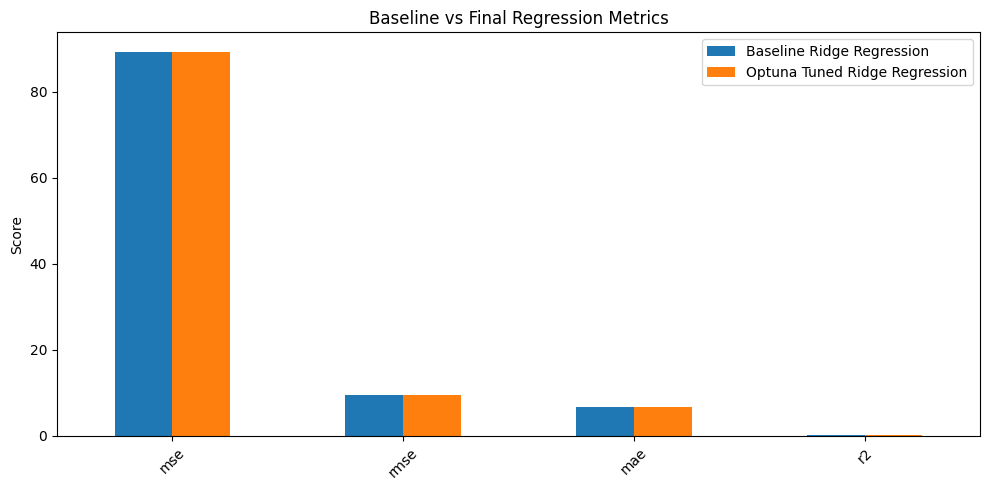

In [15]:
# ============================================================
# 15. Compare baseline and final model metrics
# ============================================================

comparison_df = pd.DataFrame([
    {"model": "Baseline Ridge Regression", **baseline_metrics},
    {"model": "Optuna Tuned Ridge Regression", **final_metrics}
])

display(comparison_df)

metric_cols = ["mse", "rmse", "mae", "r2"]
comparison_df.set_index("model")[metric_cols].T.plot(kind="bar", figsize=(10, 5))
plt.title("Baseline vs Final Regression Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

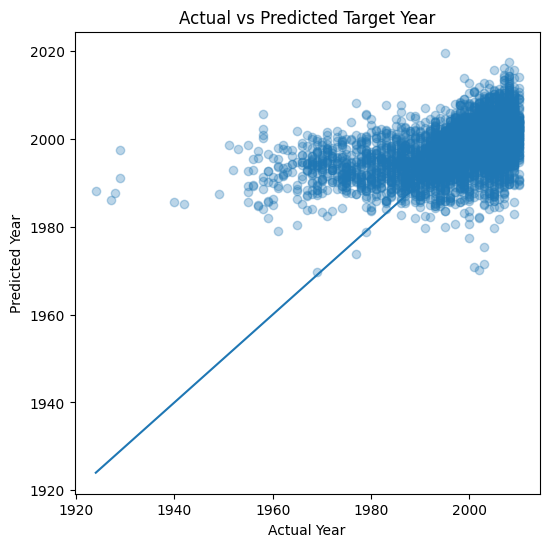

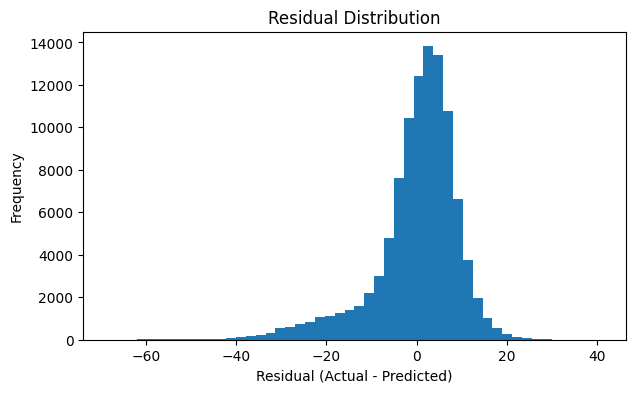

In [16]:
# ============================================================
# 16. Actual vs Predicted visualization
# ============================================================

plot_sample_size = min(5000, len(y_test))
plot_indices = np.random.RandomState(RANDOM_STATE).choice(len(y_test), size=plot_sample_size, replace=False)

y_test_array = np.asarray(y_test)
y_pred_array = np.asarray(y_pred)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_array[plot_indices], y_pred_array[plot_indices], alpha=0.3)
plt.plot([y_test_array.min(), y_test_array.max()], [y_test_array.min(), y_test_array.max()])
plt.title("Actual vs Predicted Target Year")
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.show()

residuals = y_test_array - y_pred_array
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=50)
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

## 14. Result Interpretation

The model performance should be interpreted using multiple metrics rather than a single score. RMSE and MAE show how far the model predictions are from the actual release year. R² shows how much target variation is explained by the model.

If RMSE and MAE are relatively high, it means the audio features may not fully explain the release year, or the relationship between audio characteristics and release year is complex. Since Ridge Regression is a linear model, it provides a stable baseline but may not capture all nonlinear patterns in the dataset.

## 15. Local Interpretation with LIME

LIME is used to explain an individual prediction. It identifies which features contributed most strongly to a specific predicted year.

Because LIME can be computationally expensive on large datasets, the explainer is created using a representative subset of the training data. This does not change the trained model; it only makes the explanation step efficient and stable.

Actual target year: 2008.0
Predicted target year: 2002.7584291126095
Top LIME feature contributions:


,feature_condition,contribution
0,feature_2 <= -27.34,5.912259
1,feature_6 <= -18.89,4.615256
2,feature_13 > 43.75,2.440819
3,feature_14 > 3093.79,1.719855
4,feature_11 > 2.47,-1.554102
5,40.03 < feature_1 <= 44.23,-1.231182
6,feature_85 > 8.39,1.123121
7,feature_27 > 160.42,1.109425
8,feature_58 <= -119.46,-1.107340
9,feature_57 > 222.63,-1.073807


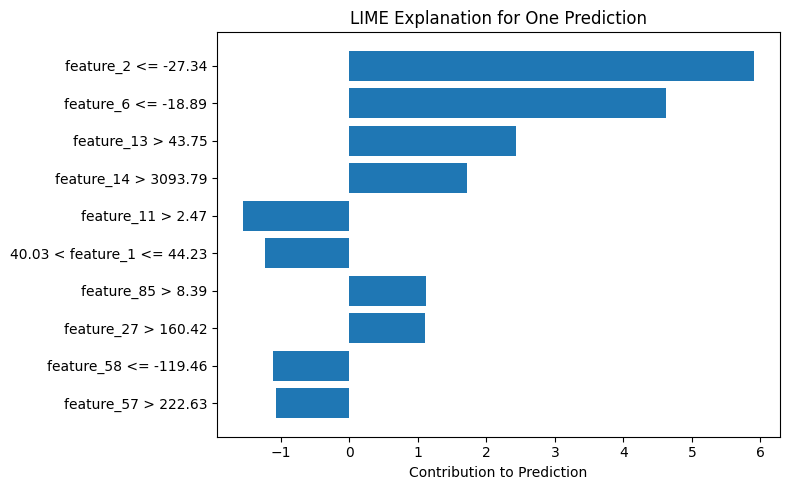

In [17]:
# ============================================================
# 17. LIME interpretation for one prediction
# ============================================================

# Prepare a manageable subset for the LIME explainer.
LIME_SAMPLE_SIZE = min(5000, len(X_train_clipped))
lime_sample = X_train_clipped.sample(n=LIME_SAMPLE_SIZE, random_state=RANDOM_STATE)

# LIME expects numpy arrays for the training data used by the explainer.
explainer = LimeTabularExplainer(
    training_data=lime_sample.values,
    feature_names=feature_cols,
    mode="regression",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)


def lime_predict(input_array):
    """Prediction wrapper for LIME. It converts numpy arrays back to a DataFrame."""
    input_df = pd.DataFrame(input_array, columns=feature_cols)
    input_df = clip_features(input_df, lower_bounds, upper_bounds)
    return final_model.predict(input_df)

# Explain the first test instance.
instance_index = 0
instance = X_test_clipped.iloc[instance_index].values

lime_exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=lime_predict,
    num_features=10
)

lime_result_df = pd.DataFrame(lime_exp.as_list(), columns=["feature_condition", "contribution"])

print("Actual target year:", y_test.iloc[instance_index])
print("Predicted target year:", y_pred[instance_index])
print("Top LIME feature contributions:")
display(lime_result_df)

# Visualize LIME explanation as a simple horizontal bar chart.
plt.figure(figsize=(8, 5))
plt.barh(lime_result_df["feature_condition"], lime_result_df["contribution"])
plt.title("LIME Explanation for One Prediction")
plt.xlabel("Contribution to Prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 16. Save Output Artifacts

The metric comparison table is saved to Google Drive so it can be referenced later in the GitHub README.

In [18]:
# ============================================================
# 18. Save output artifacts
# ============================================================

OUTPUT_DIR = "/content/drive/MyDrive/uts_regression_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

comparison_path = os.path.join(OUTPUT_DIR, "regression_model_comparison.csv")
lime_path = os.path.join(OUTPUT_DIR, "regression_lime_explanation.csv")

comparison_df.to_csv(comparison_path, index=False)
lime_result_df.to_csv(lime_path, index=False)

print("Metric comparison saved to:", comparison_path)
print("LIME explanation saved to:", lime_path)
print("MLflow runs are saved in the mlruns directory of the current runtime.")

Metric comparison saved to: /content/drive/MyDrive/uts_regression_outputs/regression_model_comparison.csv
LIME explanation saved to: /content/drive/MyDrive/uts_regression_outputs/regression_lime_explanation.csv
MLflow runs are saved in the mlruns directory of the current runtime.


## 17. Conclusion

This notebook successfully implements an end-to-end regression pipeline for predicting song release year from numerical audio features.

The workflow includes data loading, structure validation, EDA, missing value analysis, outlier handling, feature preparation, preprocessing, baseline modeling, Optuna hyperparameter tuning, MLflow tracking, model evaluation, and LIME interpretation.

Ridge Regression is used as a stable and efficient baseline model. The final model is tuned using Optuna and evaluated with MSE, RMSE, MAE, and R². LIME is used to provide a local explanation for an individual prediction, making the result more interpretable.

Possible future improvements include testing nonlinear models, increasing Optuna trials, adding more advanced feature selection, or comparing the Machine Learning model with a Deep Learning model.